# 04 - Repurchase Prediction

This notebook predicts whether a customer will make a repeat purchase within a fixed prediction window, using only information available up to the end of an observation window — the central discipline being avoiding data leakage from the future into the features.

## Research Questions

1. Who is likely to repurchase within the next 90 days, and at what decision threshold should we act on that prediction?
2. Does the model add value over a naive baseline, once evaluated honestly on time-based (not random) splits?

## Plan

0. Setup & Loading
1. Decision — Observation / Prediction Window Split
2. Feature Engineering (observation window only)
3. Target Construction
4. Train / Test Split (time-based)
5. Baseline Models
6. Model Comparison & Evaluation
7. Threshold Optimization
8. Feature Importance


# 0. Setup & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
from pathlib import Path
from IPython.display import display, Markdown

PROC = Path("../data/processed")
clean = pd.read_parquet(PROC / "clean_transactions.parquet")
purchases = clean[~clean["IsCancellation"]].copy()

display(Markdown(f"""
### Input
* **Purchase rows:** `{len(purchases):,}`
* **Date range:** `{purchases['InvoiceDate'].min()}` to `{purchases['InvoiceDate'].max()}`
"""))



### Input
* **Purchase rows:** `803,001`
* **Date range:** `2009-12-01 07:45:00` to `2011-12-09 12:50:00`


# 1. Decision — Observation / Prediction Window Split

To predict repurchase without leaking future information, the timeline is split in two:

- **Observation window**: all data up to a cutoff date. Features are computed *only* from this window.
- **Prediction window**: the 90 days immediately after the cutoff. The target is whether the customer purchases at least once in this window.

The cutoff is set so the prediction window ends before the last date in the dataset — otherwise, customers whose prediction window would extend past the data's end could never be labeled correctly (we simply wouldn't have the data to know).

In [2]:
PREDICTION_WINDOW_DAYS = 90

max_date = purchases["InvoiceDate"].max()
CUTOFF_DATE = max_date - pd.Timedelta(days=PREDICTION_WINDOW_DAYS)

display(Markdown(f"""
* **Dataset end date:** `{max_date}`
* **Prediction window:** `{PREDICTION_WINDOW_DAYS}` days
* **Cutoff date (end of observation window):** `{CUTOFF_DATE}`
"""))

obs = purchases[purchases["InvoiceDate"] <= CUTOFF_DATE].copy()
pred_window = purchases[
    (purchases["InvoiceDate"] > CUTOFF_DATE) & (purchases["InvoiceDate"] <= max_date)
].copy()

display(Markdown(f"* **Observation-window rows:** `{len(obs):,}`"))
display(Markdown(f"* **Prediction-window rows:** `{len(pred_window):,}`"))


C:\Users\jboul\AppData\Local\Temp\ipykernel_14604\153080250.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  CUTOFF_DATE = max_date - pd.Timedelta(days=PREDICTION_WINDOW_DAYS)



* **Dataset end date:** `2011-12-09 12:50:00`
* **Prediction window:** `90` days
* **Cutoff date (end of observation window):** `2011-09-10 12:50:00`


* **Observation-window rows:** `641,995`

* **Prediction-window rows:** `161,006`

**Action:** report the row counts. If the prediction window contains very few rows relative to the observation window, the resulting target may be highly imbalanced — worth knowing before building features, since it affects which metrics matter most in section 6 (PR-AUC over ROC-AUC on a rare positive class).

# 2. Feature Engineering (observation window only)

Every feature below is computed strictly from `obs` (data up to the cutoff). None may reference `pred_window` — that would be leakage.

In [3]:
customers_at_cutoff = obs["Customer ID"].unique()

features = obs.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (CUTOFF_DATE - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineRevenue", "sum"),
    AvgBasketValue=("LineRevenue", lambda x: x.sum() / obs.loc[x.index, "Invoice"].nunique()),
    Tenure=("InvoiceDate", lambda x: (CUTOFF_DATE - x.min()).days),
    NDistinctProducts=("StockCode", "nunique"),
).reset_index()

# Cancellation rate as an auxiliary signal (section 1 of notebook 02 established this is informative)
cancel_rate = clean[clean["InvoiceDate"] <= CUTOFF_DATE].groupby("Customer ID").agg(
    TotalInv=("Invoice", "nunique"),
    CancelledInv=("Invoice", lambda x: x[clean.loc[x.index, "IsCancellation"]].nunique()),
)
cancel_rate["CancellationRate"] = (cancel_rate["CancelledInv"] / cancel_rate["TotalInv"]).fillna(0)
features = features.merge(cancel_rate[["CancellationRate"]], on="Customer ID", how="left")
features["CancellationRate"] = features["CancellationRate"].fillna(0)

display(Markdown(f"**Customers with at least one observation-window purchase:** `{len(features):,}`"))
display(features.describe().round(2))


**Customers with at least one observation-window purchase:** `5,257`

,Recency,Frequency,Monetary,AvgBasketValue,Tenure,NDistinctProducts,CancellationRate
count,5257.00,5257.00,5257.00,5257.00,5257.00,5257.00,5257.00
mean,206.29,5.72,2673.88,377.73,431.12,74.55,0.11
std,174.24,11.25,12431.45,639.87,180.68,105.00,0.17
min,0.00,1.00,1.55,1.55,0.00,1.00,0.00
25%,49.00,1.00,322.40,178.60,311.00,18.00,0.00
50%,163.00,3.00,797.96,282.44,473.00,41.00,0.00
75%,324.00,6.00,2106.65,418.07,586.00,92.00,0.21
max,648.00,287.00,484615.10,25784.32,648.00,2180.00,0.80


**Action:** report the `describe()` output. Check in particular whether `Recency`, `Tenure` and `Monetary` look sensible (no negative tenure, no absurd outliers) before moving on — a bug in the window logic would most likely show up here first.

# 3. Target Construction

The target is binary: did the customer make at least one purchase in the 90-day prediction window?

In [4]:
repurchasers = set(pred_window["Customer ID"].unique())
features["WillRepurchase"] = features["Customer ID"].isin(repurchasers).astype(int)

target_rate = features["WillRepurchase"].mean() * 100
display(Markdown(f"**Repurchase rate in the {PREDICTION_WINDOW_DAYS}-day window:** `{target_rate:.1f}%`"))
display(features["WillRepurchase"].value_counts())


**Repurchase rate in the 90-day window:** `43.6%`

WillRepurchase
0    2967
1    2290
Name: count, dtype: int64

**Action:** report the repurchase rate and class counts. This number determines everything downstream: if it is far from 50/50 (likely, since 90 days is short relative to typical purchase intervals seen in notebook 03), the benchmark comparison and metric choice in section 6 must be read accordingly — a naive "always predict no repurchase" baseline will already score deceptively high on accuracy.

# 4. Train / Test Split (time-based)

A random split would leak information: two purchases from the same customer close in time can end up on opposite sides of a random split, letting the model implicitly learn from a customer's own future behaviour. Instead, we split by an *earlier* cutoff within the observation window itself, so the test set genuinely simulates predicting forward in time on unseen data.

In [5]:
# Re-derive an earlier "training cutoff" strictly inside the observation window,
# so both training and test features are still computed causally.
TRAIN_CUTOFF_DAYS_BACK = 90
TRAIN_CUTOFF_DATE = CUTOFF_DATE - pd.Timedelta(days=TRAIN_CUTOFF_DAYS_BACK)

obs_train_window = obs[obs["InvoiceDate"] <= TRAIN_CUTOFF_DATE]
pred_train_window = obs[
    (obs["InvoiceDate"] > TRAIN_CUTOFF_DATE) & (obs["InvoiceDate"] <= CUTOFF_DATE)
]

train_features = obs_train_window.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (TRAIN_CUTOFF_DATE - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineRevenue", "sum"),
    AvgBasketValue=("LineRevenue", lambda x: x.sum() / obs_train_window.loc[x.index, "Invoice"].nunique()),
    Tenure=("InvoiceDate", lambda x: (TRAIN_CUTOFF_DATE - x.min()).days),
    NDistinctProducts=("StockCode", "nunique"),
).reset_index()

train_repurchasers = set(pred_train_window["Customer ID"].unique())
train_features["WillRepurchase"] = train_features["Customer ID"].isin(train_repurchasers).astype(int)

FEATURE_COLS = ["Recency", "Frequency", "Monetary", "AvgBasketValue", "Tenure", "NDistinctProducts", "CancellationRate"]

# Training set: features as of TRAIN_CUTOFF_DATE, predicting the window that leads up to CUTOFF_DATE
X_train = train_features[["Recency", "Frequency", "Monetary", "AvgBasketValue", "Tenure", "NDistinctProducts"]]
y_train = train_features["WillRepurchase"]

# Test set: features as of CUTOFF_DATE (built in section 2), predicting the true holdout window
X_test = features[["Recency", "Frequency", "Monetary", "AvgBasketValue", "Tenure", "NDistinctProducts"]]
y_test = features["WillRepurchase"]

display(Markdown(f"""
* **Training cutoff:** `{TRAIN_CUTOFF_DATE}` | **Training customers:** `{len(X_train):,}` | **Positive rate:** `{y_train.mean()*100:.1f}%`
* **Test cutoff:** `{CUTOFF_DATE}` | **Test customers:** `{len(X_test):,}` | **Positive rate:** `{y_test.mean()*100:.1f}%`
"""))


C:\Users\jboul\AppData\Local\Temp\ipykernel_14604\3233792370.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  TRAIN_CUTOFF_DATE = CUTOFF_DATE - pd.Timedelta(days=TRAIN_CUTOFF_DAYS_BACK)



* **Training cutoff:** `2011-06-12 12:50:00` | **Training customers:** `4,953` | **Positive rate:** `32.2%`
* **Test cutoff:** `2011-09-10 12:50:00` | **Test customers:** `5,257` | **Positive rate:** `43.6%`


**Action:** report the two positive rates. If they differ substantially, that itself is worth a sentence in the write-up — it would mean repurchase behaviour shifted between the two periods (seasonality is a likely candidate, given the run-up to Christmas in a giftware business), which affects how much the test-set score generalizes to other times of year.

# 5. Baseline Models

In [6]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

models = {"Dummy (stratified)": dummy, "Logistic Regression": logreg, "Random Forest": rf}


# 6. Model Comparison & Evaluation

ROC-AUC alone can be misleading on an imbalanced target — it is shown alongside PR-AUC, which is more sensitive to performance on the minority (positive) class.

### Model comparison

,Model,ROC-AUC,PR-AUC
0,Dummy (stratified),0.4967,0.4340
1,Logistic Regression,0.7903,0.7551
2,Random Forest,0.7751,0.7522


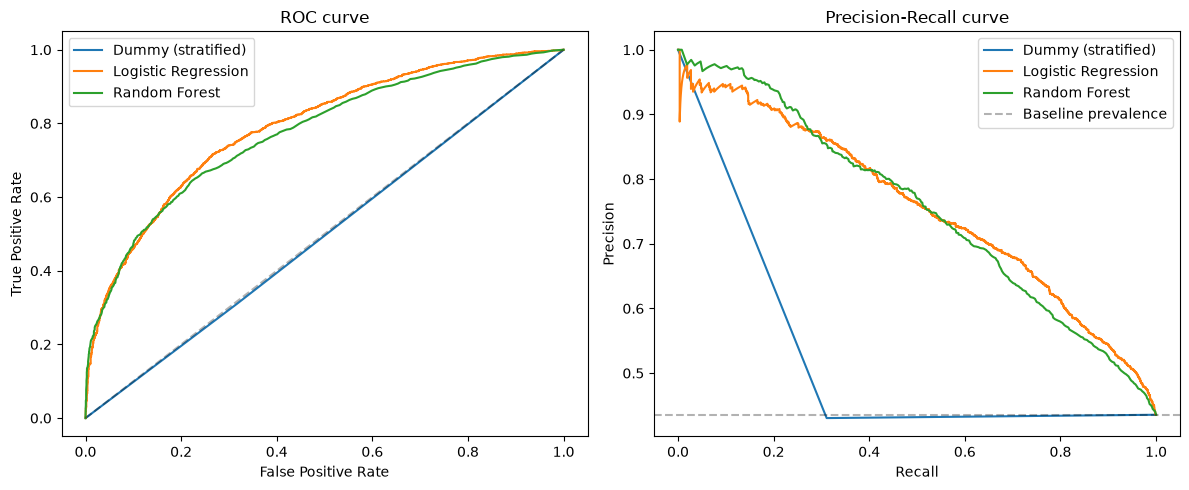

In [7]:
results = []
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    results.append({"Model": name, "ROC-AUC": roc_auc, "PR-AUC": pr_auc})

results_df = pd.DataFrame(results)
display(Markdown("### Model comparison"))
display(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3, label="Baseline prevalence")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()


**Action:** report the comparison table. The Random Forest should beat both the dummy baseline and logistic regression on PR-AUC for this to be a meaningful model — if it does not, that is a real result to report honestly (as with the 0.644 ROC-AUC on the readmission project), not a reason to keep tuning until a better number appears.

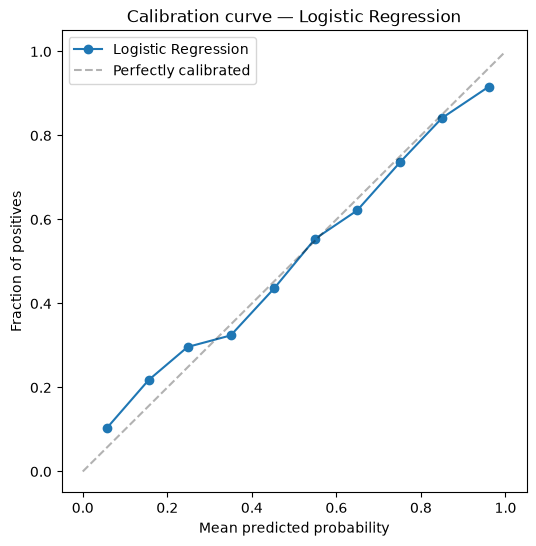

In [8]:
best_model_name = results_df.sort_values("PR-AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

y_proba_best = best_model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", label=best_model_name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title(f"Calibration curve — {best_model_name}")
ax.legend()
plt.show()


**Action:** report whether the calibration curve sits close to the diagonal. A model can have good ranking ability (decent ROC/PR-AUC) while still being poorly calibrated — meaning its predicted probabilities should not be read literally, only its relative ranking of customers, which matters for the next section.

# 7. Threshold Optimization

Instead of the default 0.5 cutoff, the decision threshold is chosen from an explicit business cost assumption: the cost of contacting a customer who wasn't going to repurchase anyway, versus the value of successfully retaining one who was at risk.

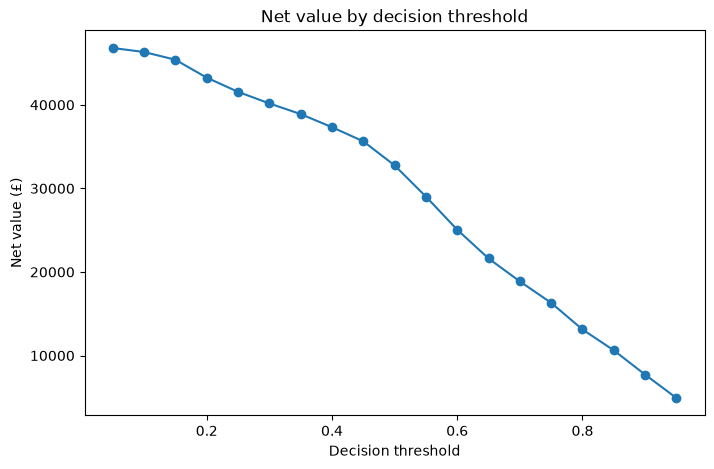

**Threshold maximizing net value:** `0.05`

In [9]:
COST_OF_CONTACT = 2.0     # <-- set to a realistic assumption, e.g. cost of an email/discount campaign
VALUE_OF_RETENTION = 25.0  # <-- set to a realistic assumption, e.g. average order value at stake

thresholds = np.linspace(0.05, 0.95, 19)
net_values = []

for t in thresholds:
    y_pred = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # Net value: correctly identified repurchasers we successfully targeted,
    # minus the cost of contacting everyone we flagged (true and false positives)
    net_value = tp * VALUE_OF_RETENTION - (tp + fp) * COST_OF_CONTACT
    net_values.append(net_value)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, net_values, marker="o")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Net value (£)")
ax.set_title("Net value by decision threshold")
plt.show()

best_threshold = thresholds[np.argmax(net_values)]
display(Markdown(f"**Threshold maximizing net value:** `{best_threshold:.2f}`"))


**Action:** report the optimal threshold and the shape of the curve. The two cost assumptions above are placeholders — replace them with real or at least defensible figures before treating this as a genuine business recommendation, and say explicitly in the write-up that the threshold is only as good as these assumptions.

# 8. Feature Importance

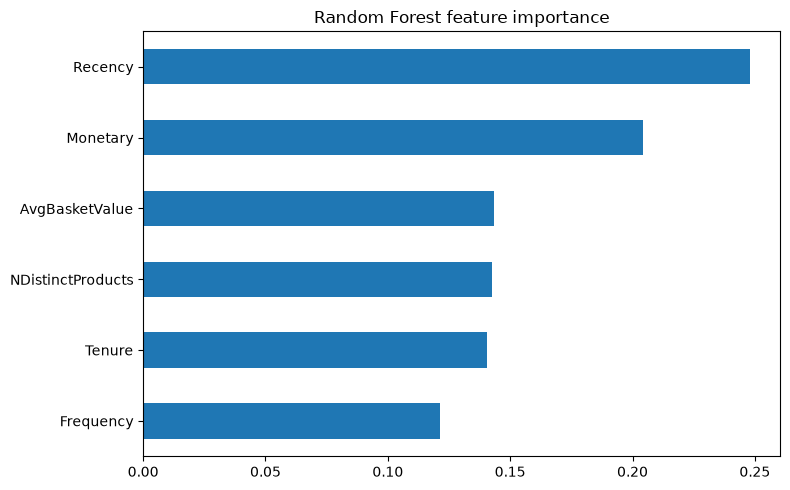

Recency              0.2479
Monetary             0.2042
AvgBasketValue       0.1433
NDistinctProducts    0.1428
Tenure               0.1403
Frequency            0.1215
dtype: float64

In [10]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax)
ax.set_title("Random Forest feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(importances.round(4))


**Action:** report the ranked importances. If `Recency` dominates heavily, that is unsurprising (it usually does in repurchase-timing problems) but worth stating plainly rather than treated as a discovery — the more interesting result for a write-up is typically the *second*-most important feature, since it says something the obvious one does not.